# Benchmarks - Plot

**Main considerations when implementing Magma's Ploting functions*

* We want composite plot functions for the various scenarios we encounter throughout the framework


---
## Setup

In [1]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from functools import partial
from copy import deepcopy

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

from jax import jit, vmap
import jax.numpy as jnp
import jax.random as jr

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [5]:
# Local
from kernax import AbstractKernel, DiagKernel, ExpKernel, BatchKernel
from MagmaClustPy.custom_kernels import SEMagmaKernel
from MagmaClustPy.hyperpost import hyperpost
from MagmaClustPy.hp_optimisation import optimise_mean_kernel, optimise_task_kernel
from MagmaClustPy.utils import preprocess_db, compute_mapping, split_db
from MagmaClustPy.linalg import lexicographic_sort, cho_solve, cho_factor
from MagmaClustPy.plot import plot_prediction
from MagmaClustPy.means import ZeroMean
from MagmaClustPy.models import BaseLikelihood, MagmaClust, Magma
from MagmaClustPy.mixture import update_mixture

INFO:2025-12-17 11:37:44,976:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2025-12-17 11:37:44,976 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [6]:
# Config
key = jax.random.PRNGKey(0)
test_db_size = "small"
nb_cluster = 4
pred_id = 0
grid_size = 250  # number of points in the grid
grid_margin = 5  # grid goes from min(all_inputs) - margin to max(all_inputs) + margin
train_pred_ratio = 0.8  # ratio of train/pred tasks
pred_test_ratio = 0.7  # ratio of pred/test points in each pred task

---
## Data

---
## Current implementation

In [7]:
import MagmaClustPy

plot_predictions_magma_old = MagmaClustPy.models.Magma.plot_predictions
plot_mean_process_magma_old = MagmaClustPy.models.Magma.plot_mean_process
plot_predictions_magmaclust_old = MagmaClustPy.models.MagmaClust.plot_predictions
plot_mean_process_magmaclust_old = MagmaClustPy.models.MagmaClust.plot_mean_process

---
## Custom implementation(s)

In [8]:
from typing import Optional, Literal
from jax import Array
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from random import choice

In [9]:
def sample(self, nb_samples: int, jitter: Array = jnp.array(1e-4), key: Array = jr.PRNGKey(42)) -> Array:
	eye = jitter * jnp.eye(len(self.cov_pred[0]))
	sample_task = lambda mean, cov: jr.multivariate_normal(key, mean, cov+eye,
	                              shape=(nb_samples,))
	return vmap(sample_task)(self.mean_pred, self.cov_pred)

In [10]:
# Utility plotting functions
def plot_points(inputs: Array, outputs: Array, color=None, marker=".", point_alpha: float=0.5, label: Optional[str]=None, zorder: float=2, fig=None, ax=None):
	"""
	Plot points with a specific color and alpha.

	:return: completed fig and ax
	"""
	# Check parameters consistency
	# fig, ax must be both provided or none
	if (fig is None) + (ax is None) not in (0, 2):
		raise ValueError("fig and ax must be both provided or none.")
	if not (inputs.ndim == 1 or inputs.ndim == 2 and inputs.shape[-1] == 1):
		raise ValueError(f"`plot_points()` only works for 1D input points, but got shape {inputs.shape}. You should call it with the specific dimension you wish to plot.")
	if not (outputs.ndim == 1 or outputs.ndim == 2 and outputs.shape[-1] == 1):
		raise ValueError(f"`plot_points()` only works for 1D output points, but got shape {outputs.shape}. You should call it with the specific dimension you wish to plot.")
	if len(inputs) != len(outputs):
		raise ValueError(f"Every input point should have a corresponding output point, but got {len(inputs)} inputs and {len(outputs)} outputs.")

	# Squeeze inputs and outputs if needed
	if inputs.ndim == 2:
		inputs = inputs.squeeze()
	if outputs.ndim == 2:
		outputs = outputs.squeeze()

	# Create fig and ax if not provided
	created_fig = False
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))
		created_fig = True

	# If color is not provided, chose one in cmap's tab10
	if color is None:
		choice([plt.get_cmap("tab10")(i) for i in range(10)])

	# Plot points
	ax.scatter(inputs, outputs, color=color, alpha=point_alpha, marker=marker, label=label, zorder=zorder)

	if created_fig and label is not None:
		ax.legend()

	return fig, ax

def plot_tasks(inputs: Array, outputs: Array, color=None, point_alpha=0.5, task_label: bool=False, points_label: Optional[str]=None, zorder: float=2, fig=None, ax=None):
	"""
	Plots tasks as points. Point in the same task share the same color.
	This function is a wrapper around plot_points, calling it for every task.

	:return:
	"""
	# Check parameters consistency
	# fig, ax must be both provided or none
	if (fig is None) + (ax is None) not in (0, 2):
		raise ValueError("fig and ax must be both provided or none.")
	if not (inputs.ndim == 2 or inputs.ndim == 3 and inputs.shape[-1] == 1):
		raise ValueError(f"`plot_tasks()` only works for 1D input points in batched sequences, but got shape {inputs.shape}. You should call it with the specific dimension you wish to plot.")
	if not (outputs.ndim == 2 or outputs.ndim == 3 and outputs.shape[-1] == 1):
		raise ValueError(f"`plot_tasks()` only works for 1D output points in batched sequences, but got shape {outputs.shape}. You should call it with the specific dimension you wish to plot.")
	if len(inputs) != len(outputs):
		raise ValueError(f"Every input point should have a corresponding output point, but got {len(inputs)} inputs and {len(outputs)} outputs.")

	# Squeeze inputs and outputs if needed
	if inputs.ndim == 3:
		inputs = inputs[:, :, 0]
	if outputs.ndim == 3:
		outputs = outputs[:, :, 0]

	# Create fig and ax if not provided
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	# Call `plot_points` for each task
	for i, (task_inputs, task_outputs) in enumerate(zip(inputs, outputs)):
		fig, ax = plot_points(task_inputs, task_outputs, color=color, point_alpha=point_alpha, label=f"Task {i}" if task_label else points_label, zorder=zorder, fig=fig, ax=ax)

	return fig, ax


def plot_process(grid: Array, mean: Array, cov: Array,
                 color=None, linestyle="-", linewidth=2, curve_alpha: float=1, ci_alpha: float=0.3, label: Optional[str]=None, zorder: float=2,
                 fig=None, ax=None):
	"""
	Plot a gaussian process as a function with confidence intervals, with a specific color and alpha.
	This function can be used to plot mean-processes as well as predictions, for example.

	:return:
	"""
	# Check parameters consistency
	# fig, ax must be both provided or none
	if (fig is None) + (ax is None) not in (0, 2):
		raise ValueError("fig and ax must be both provided or none.")
	if not (grid.ndim == 1 or grid.ndim == 2 and grid.shape[-1] == 1):
		raise ValueError(f"`plot_process()` only works for 1D grid points, but got shape {grid.shape}. You should call it with the specific dimension you wish to plot.")
	if not (mean.ndim == 1 or mean.ndim == 2 and mean.shape[-1] == 1):
		raise ValueError(f"`plot_process()` only works for scalar-valued processes, but got shape {mean.shape}. You should call it with the specific dimension you wish to plot.")
	if not (cov.ndim == 2):
		raise ValueError(f"`plot_process()` only works for scalar-valued covariances, but got shape {cov.shape}. You should call it with the specific dimension you wish to plot.")
	if len(grid) != len(mean) or len(grid) != len(cov):
		raise ValueError(f"Every grid point should have a corresponding mean process point and covariance row, but got {len(grid)} grid, {len(mean)} mean and {len(cov)} covariance.")

	# Squeeze grid and mean if needed
	if grid.ndim == 2:
		grid = grid[:, 0]
	if mean.ndim == 2:
		mean = mean[:, 0]

	# Create fig and ax if not provided
	created_fig = False
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))
		created_fig = True

	# If color is not provided, chose one in cmap's tab10
	if color is None:
		choice([plt.get_cmap("tab10")(i) for i in range(10)])

	# Plot CI
	std = jnp.sqrt(jnp.diag(cov))
	ax.fill_between(grid, mean - 2*std, mean + 2*std,
							color=color, alpha=ci_alpha, label=label, zorder=zorder)

	# Plot process
	ax.plot(grid, mean, color=color, alpha=curve_alpha, linewidth=linewidth, linestyle=linestyle, label=label, zorder=zorder)

	if created_fig and label is not None:
		ax.legend()

	return fig, ax

def plot_samples(grid: Array, samples: Array,
                 color=None, linestyle="-", linewidth=2, alpha: float=1, label: Optional[str]=None, zorder: float=2,
                 fig=None, ax=None):
	"""
	Plot samples of a gaussian process as functions, with a specific color and alpha.

	:return:
	"""
	# Check parameters consistency
	# fig, ax must be both provided or none
	if (fig is None) + (ax is None) not in (0, 2):
		raise ValueError("fig and ax must be both provided or none.")
	if not (grid.ndim == 1 or grid.ndim == 2 and grid.shape[-1] == 1):
		raise ValueError(f"`plot_samples()` only works for 1D grid points, but got shape {grid.shape}. You should call it with the specific dimension you wish to plot.")
	if not (samples.ndim == 2 or samples.ndim == 3 and samples.shape[-1] == 1):
		raise ValueError(f"`plot_samples()` only works for scalar-valued processes, but got shape {samples.shape}. You should call it with the specific dimension you wish to plot.")
	if len(grid) != len(samples[0]):
		raise ValueError(f"Every sample should have a value for each grid point, but got {samples.shape} sample shape and {grid.shape} grid shape.")

	# Squeeze grid and mean if needed
	if grid.ndim == 2:
		grid = grid[:, 0]
	if samples.ndim == 3:
		samples = samples[:, :, 0]

	# Create fig and ax if not provided
	created_fig = False
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))
		created_fig = True

	for sample in samples:
		# If color is not provided, chose one in cmap's tab10
		if color is None:
			choice([plt.get_cmap("tab10")(i) for i in range(10)])

		# Plot process
		ax.plot(grid, sample, color=color, alpha=alpha, linewidth=linewidth, linestyle=linestyle, label=label, zorder=zorder)

	if created_fig and label is not None:
		ax.legend()

	return fig, ax

In [11]:
# Model-specific plotting functions for Magma

def plot_predictions_magma(self, plot_as: Literal["samples", "process"]="samples", task_id=0, nb_samples: int=100, include_train_points=True, key: Array=jr.PRNGKey(42), fig=None, ax=None):
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	if include_train_points:
		plot_tasks(self.padded_inputs_train, self.padded_outputs_train, point_alpha=0.1, fig=fig, ax=ax)

	# Plot prediction
	if plot_as == "samples":
		key, subkey = jr.split(key)
		samples = self.sample(nb_samples, key=subkey)
		plot_samples(self.grid_pred, samples[task_id], alpha=0.3, fig=fig, ax=ax)
	else:
		plot_process(self.grid_pred, self.mean_pred[task_id], self.cov_pred[task_id], fig=fig, ax=ax)

	# Plot mean profile as dashed line with no CI
	plot_process(self.grid_pred, self.mean_pred[task_id], jnp.zeros_like(self.cov_pred[task_id]), linestyle="--", ci_alpha=0, curve_alpha=1, label="Mean profile", fig=fig, ax=ax)

	# Plot pred points
	pred_color = plt.get_cmap("tab10")(0)
	plot_points(self.padded_inputs_pred[task_id], self.padded_outputs_pred[task_id], color=pred_color, marker="o", zorder=3, fig=fig, ax=ax)

	# Plot test points
	test_color = plt.get_cmap("tab10")(1)
	plot_points(self.padded_inputs_test[task_id], self.padded_outputs_test[task_id], color=test_color, marker="o", zorder=3, fig=fig, ax=ax)

	return fig, ax


def plot_mean_process_magma(self, include_train_points=True, fig=None, ax=None):
	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	if include_train_points:
		plot_tasks(self.padded_inputs_train, self.padded_outputs_train, point_alpha=0.1, fig=fig, ax=ax)

	# Plot process
	plot_process(self.all_inputs_train, self.post_mean, self.post_cov, fig=fig, ax=ax)

	return fig, ax

In [12]:
# Model-specific plotting functions for MagmaClust

from typing import Optional
from jax import Array

def plot_predictions_magmaclust(self, plot_as: Literal["samples", "process"]="samples", task_id=0, assume_mixture: Optional[list[float]]= None, colors="mixture", nb_samples: int=100, include_train_points=True, key: Array=jr.PRNGKey(42), fig=None, ax=None):
	if colors is None:
		colors = [plt.get_cmap("tab10")(0) for _ in range(self.k)]  # all same color
	elif colors == "mixture":
		colors = [plt.get_cmap("tab10")(i) for i in range(self.k)]  # different color per cluster
	else:
		colors = [colors] * self.k  # all same provided color

	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	if include_train_points:
		plot_tasks(self.padded_inputs_train, self.padded_outputs_train, point_alpha=0.1, fig=fig, ax=ax)

	# Plot prediction
	if plot_as == "samples":
		task_mixture = jnp.round(self.mixture_pred[:, task_id] * nb_samples).astype(int).tolist()
		if assume_mixture is not None:
			task_mixture = jnp.array(assume_mixture)

		for cluster_id in range(self.k):
			nb_cluster_samples = task_mixture[cluster_id]
			if nb_cluster_samples > 0:
				key, subkey = jr.split(key)
				samples = self.sample(nb_cluster_samples, key=subkey)  # FIXME: adapt when MagmaClust.sample will work
				plot_samples(self.grid_pred, samples[task_id], alpha=0.3, color=colors[cluster_id], fig=fig, ax=ax)
	else:
		task_mixture = self.mixture_pred[:, task_id].tolist() if assume_mixture is None else assume_mixture

		for cluster_id in range(self.k):
			weight = task_mixture[cluster_id]
			if weight > 0:
				# Scale covariance by the mixture weight
				plot_process(self.grid_pred, self.means_pred[cluster_id, task_id], self.covs_pred[cluster_id, task_id], ci_alpha=0.1*weight, curve_alpha=weight, color=colors[cluster_id], fig=fig, ax=ax)

	# Plot pred points
	pred_color = plt.get_cmap("tab10")(0)
	plot_points(self.padded_inputs_pred[task_id], self.padded_outputs_pred[task_id], color=pred_color, marker="o", zorder=3, fig=fig, ax=ax)

	# Plot test points
	test_color = plt.get_cmap("tab10")(1)
	plot_points(self.padded_inputs_test[task_id], self.padded_outputs_test[task_id], color=test_color, marker="o", zorder=3, fig=fig, ax=ax)

	return fig, ax

def plot_mean_processes_magmaclust(self, include_train_points=True, alphas:float|list[float]|Literal["mixture"]="mixture", colors=None, fig=None, ax=None):
	if colors is not None and len(colors) != self.k:
		raise ValueError(f"If colors is provided, it must have length equal to the number of clusters k={self.k}, but got length {len(colors)}.")

	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	if colors is None:
		colors = [plt.get_cmap("tab10")(i) for i in range(self.k)]

	if include_train_points:
		# Plot points with color corresponding to their cluster assignment
		clust_assign = jnp.argmax(self.mixture_train, axis=0)
		for cluster_id in range(self.k):
			cluster_points_mask = clust_assign == cluster_id
			plot_tasks(self.padded_inputs_train[cluster_points_mask], self.padded_outputs_train[cluster_points_mask], point_alpha=0.1, color=colors[cluster_id], fig=fig, ax=ax)

	if alphas == "mixture":
		# Plot each cluster's mean process weighted by the mixture proportions
		alphas = self.mixture_train.mean(axis=1).tolist()
	elif isinstance(alphas, float):
		alphas = [alphas] * self.k
	elif isinstance(alphas, list):
		if len(alphas) != self.k:
			raise ValueError(f"If alpha is a list, it must have length equal to the number of clusters k={self.k}, but got length {len(alphas)}.")
	else:
		raise ValueError(f"alpha must be a float, a list of floats of length k={self.k}, or 'mixture', but got {alphas}.")

	# Plot each cluster's mean process
	for mean, cov, alpha, color in zip(self.post_means, self.post_covs, alphas, colors):
		plot_process(self.all_inputs_train, mean, cov, ci_alpha=0.1, curve_alpha=alpha, color=color, fig=fig, ax=ax)

	return fig, ax

---
## Comparison

### Magma scenarios

#### Shared Input, Shared HP

##### Setup

In [13]:
db = pd.read_csv(f"../datasets/K=1/{test_db_size}_shared_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [14]:
mean_kernel = SEMagmaKernel(length_scale=.3, variance=1.)
task_kernel_train = SEMagmaKernel(length_scale=.6, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kernel_pred = deepcopy(task_kernel_train)

prior_mean = ZeroMean()

likelihood = BaseLikelihood()

In [15]:
model = Magma(likelihood=likelihood, prior_mean=prior_mean, mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=True)

In [16]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [17]:
model.fit()

2025-12-17 11:37:46,195 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.30, variance=1.00)
	Task kernel: SEMagmaKernel(length_scale=0.60, variance=1.00) + Diag(Exp(2.50))
2025-12-17 11:37:47,296 - INFO - Iteration    1	Llhs:   -1019.4531,     641.0811	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=4.52, variance=5.13)
	Task kernel: SEMagmaKernel(length_scale=1.75, variance=3.70) + Diag(Exp(0.82))
2025-12-17 11:37:48,221 - INFO - Iteration    2	Llhs:   -1001.3593,     652.9033	Conv. Ratio: 0.07907	
	Mean kernel: SEMagmaKernel(length_scale=4.52, variance=5.13)
	Task kernel: SEMagmaKernel(length_scale=0.56, variance=3.57) + Diag(Exp(-0.65))
2025-12-17 11:37:48,231 - INFO - Iteration    3	Llhs:   -1006.8501,     651.1690	Conv. Ratio: 0.02073	
	Mean kernel: SEMagmaKernel(length_scale=4.52, variance=5.13)
	Task kernel: SEMagmaKernel(length_scale=0.54, variance=3.55) + Diag(Exp(-0.69))
2025-12-17 11:37:48,244 - 

In [18]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [19]:
pred_mean, pred_cov = model.predict(grid)
pred_mean.shape, pred_cov.shape

((4, 265), (4, 265, 265))

##### Test

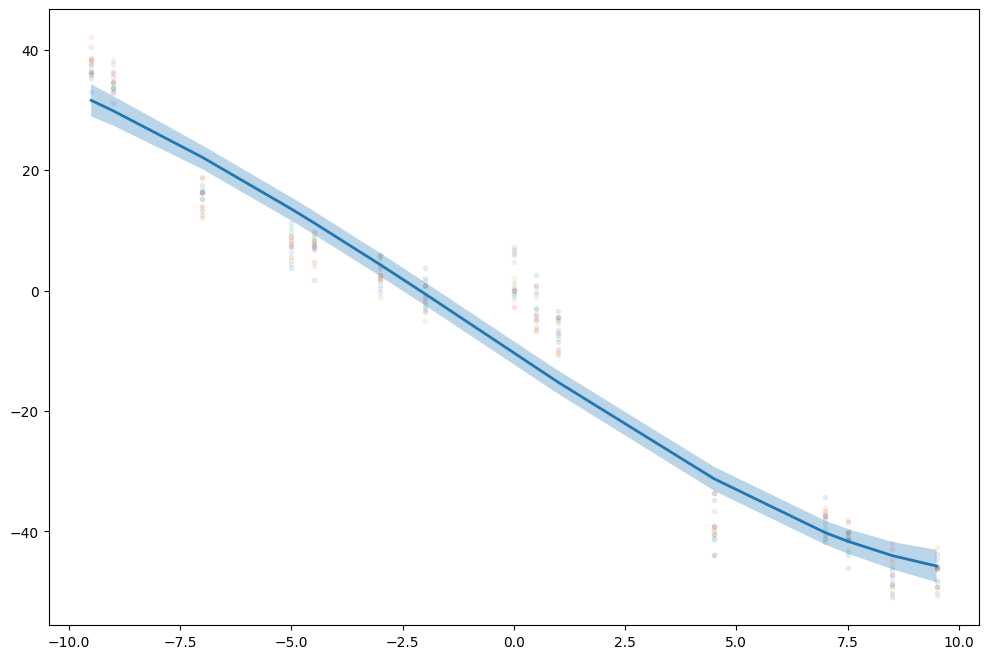

In [20]:
plot_mean_process_magma(model)
plt.show()

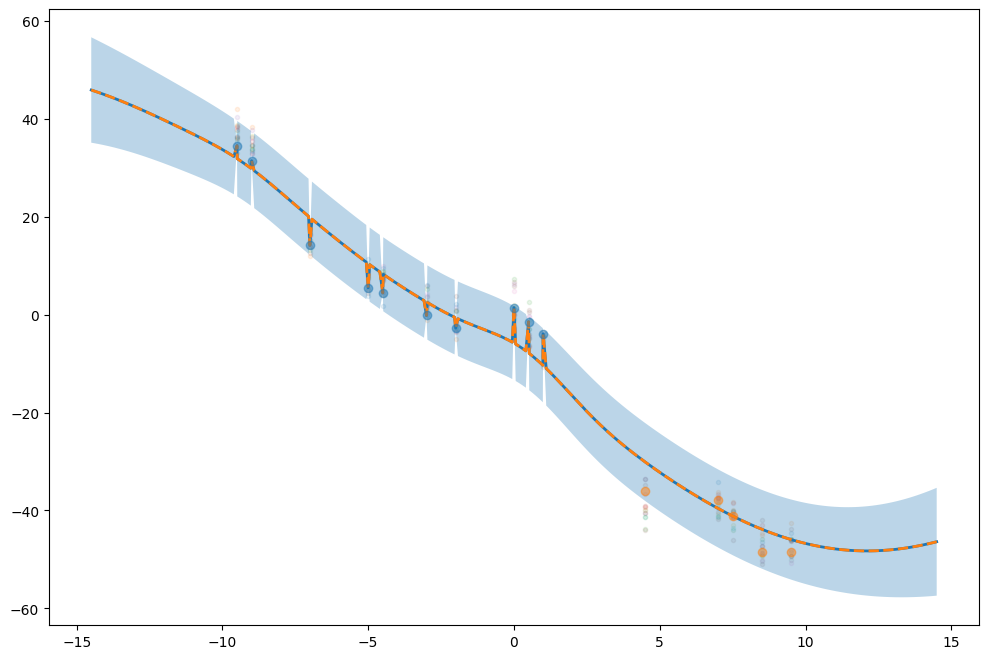

In [21]:
plot_predictions_magma(model, plot_as="process", task_id=0)
plt.show()

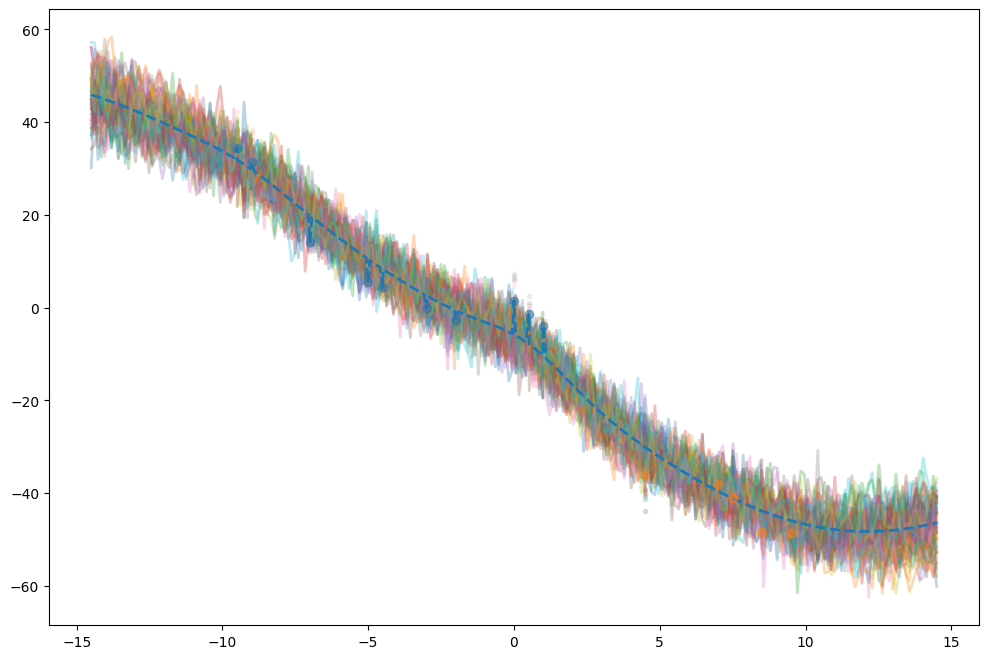

In [22]:
plot_predictions_magma(model, plot_as="samples", task_id=0, nb_samples=50)
plt.show()

#### Shared Input, Distinct HP

##### Setup

In [23]:
db = pd.read_csv(f"../datasets/K=1/{test_db_size}_shared_input_distinct_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [24]:
mean_kernel = SEMagmaKernel(length_scale=.3, variance=1.)
task_kernel_train = SEMagmaKernel(length_scale=.6, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kernel_pred = deepcopy(task_kernel_train)

prior_mean = ZeroMean()

likelihood = BaseLikelihood()

In [25]:
model = Magma(likelihood=likelihood, prior_mean=prior_mean, mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=False)

In [26]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [27]:
model.fit()

2025-12-17 11:37:49,872 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.30, variance=1.00)
	Task kernel: SEMagmaKernel(length_scale=[0.60 ± 0.00]₁₆, variance=[1.00 ± 0.00]₁₆) + Diag(Exp([2.50 ± 0.00]₁₆))
2025-12-17 11:37:50,598 - INFO - Iteration    1	Llhs:    -585.0272,     656.6077	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=3.57, variance=5.01)
	Task kernel: SEMagmaKernel(length_scale=[6.04 ± 2.12]₁₆, variance=[3.96 ± 0.46]₁₆) + Diag(Exp([2.16 ± 0.35]₁₆))
2025-12-17 11:37:51,159 - INFO - Iteration    2	Llhs:   -1000.0675,     770.0998	Conv. Ratio: 4.21271	
	Mean kernel: SEMagmaKernel(length_scale=4.48, variance=5.07)
	Task kernel: SEMagmaKernel(length_scale=[8.74 ± 2.90]₁₆, variance=[0.18 ± 2.41]₁₆) + Diag(Exp([3.52 ± 0.19]₁₆))
2025-12-17 11:37:51,179 - INFO - Iteration    3	Llhs:    -990.5053,     821.1633	Conv. Ratio: 0.26363	
	Mean kernel: SEMagmaKernel(length_scale=4.48, variance=5.07)
	Task ker

In [28]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [29]:
pred_mean, pred_cov = model.predict(grid)
pred_mean.shape, pred_cov.shape

((4, 265), (4, 265, 265))

##### Test

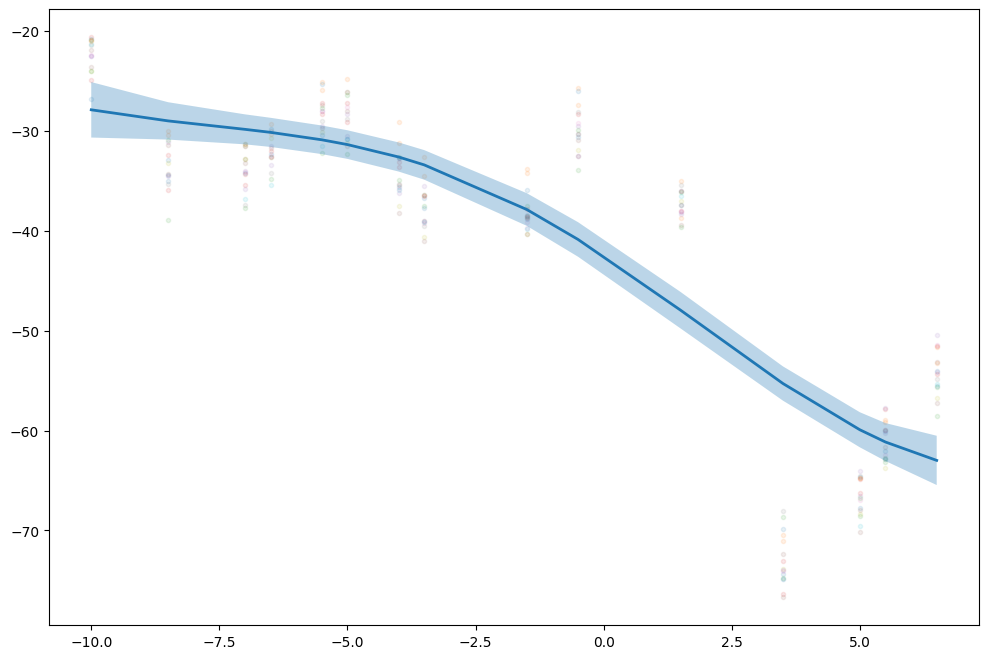

In [30]:
plot_mean_process_magma(model)
plt.show()

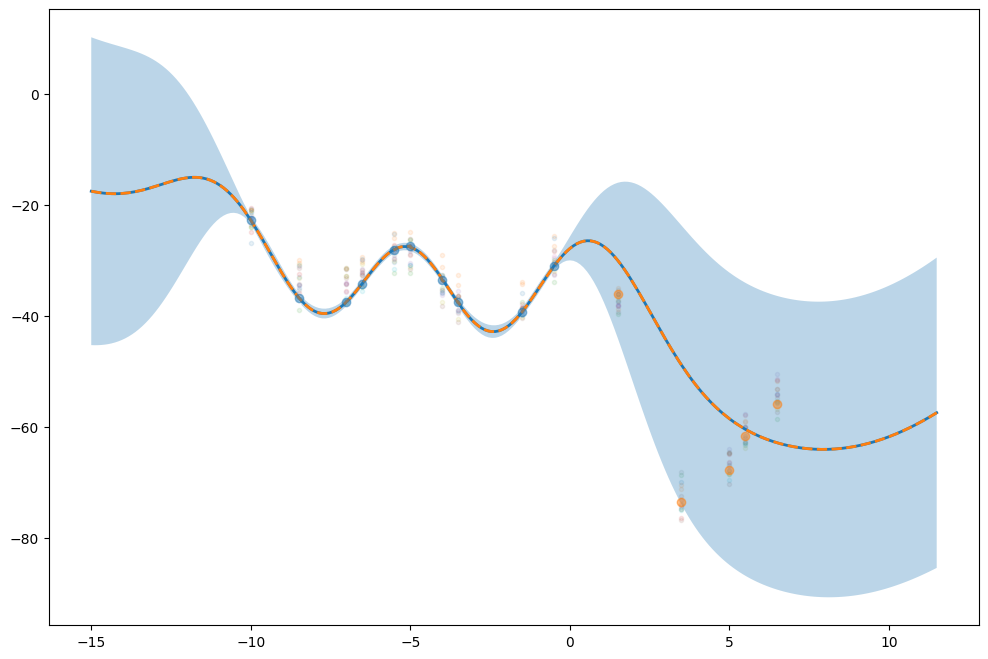

In [31]:
plot_predictions_magma(model, plot_as="process", task_id=0)
plt.show()

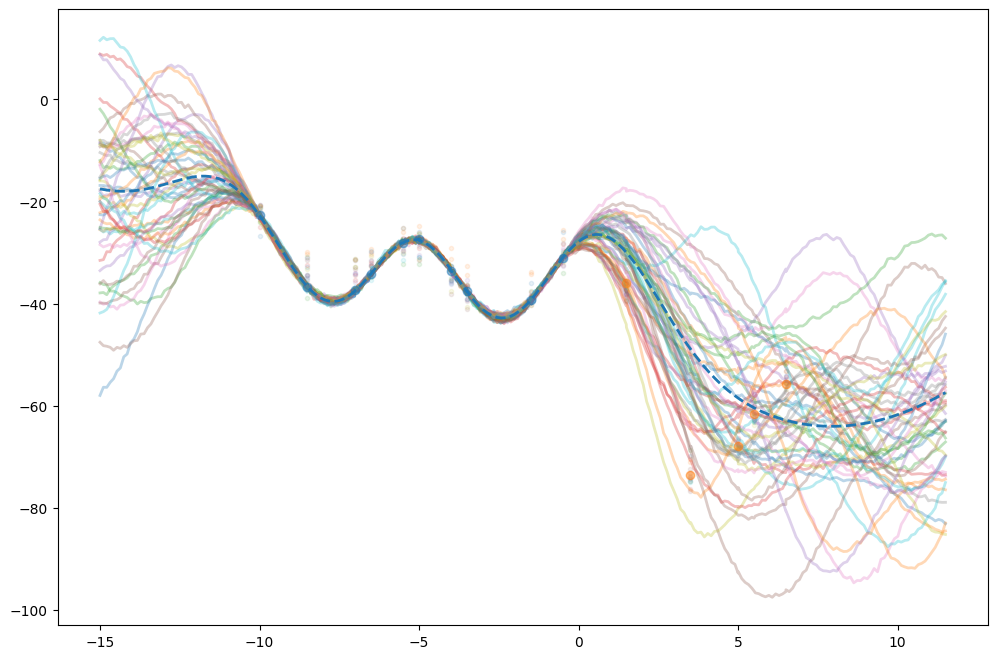

In [32]:
plot_predictions_magma(model, plot_as="samples", task_id=0, nb_samples=50)
plt.show()

#### Distinct Input, Shared HP

##### Setup

In [33]:
db = pd.read_csv(f"../datasets/K=1/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [34]:
mean_kernel = SEMagmaKernel(length_scale=.3, variance=1.)
task_kernel_train = SEMagmaKernel(length_scale=.6, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kernel_pred = deepcopy(task_kernel_train)

prior_mean = ZeroMean()

likelihood = BaseLikelihood()

In [35]:
model = Magma(likelihood=likelihood, prior_mean=prior_mean, mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=True)

In [36]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [37]:
model.fit()

2025-12-17 11:37:53,277 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.30, variance=1.00)
	Task kernel: SEMagmaKernel(length_scale=0.60, variance=1.00) + Diag(Exp(2.50))
2025-12-17 11:37:54,859 - INFO - Iteration    1	Llhs:   -4673.0532,     648.4382	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=1.31, variance=3.84)
	Task kernel: SEMagmaKernel(length_scale=6.17, variance=4.11) + Diag(Exp(2.14))
2025-12-17 11:37:55,937 - INFO - Iteration    2	Llhs:   -5241.7820,     561.8270	Conv. Ratio: 0.16283	
	Mean kernel: SEMagmaKernel(length_scale=1.31, variance=3.84)
	Task kernel: SEMagmaKernel(length_scale=7.22, variance=4.67) + Diag(Exp(1.30))
2025-12-17 11:37:56,001 - INFO - Iteration    3	Llhs:   -6177.7662,     550.4460	Conv. Ratio: 0.20243	
	Mean kernel: SEMagmaKernel(length_scale=1.35, variance=3.85)
	Task kernel: SEMagmaKernel(length_scale=8.25, variance=5.49) + Diag(Exp(1.15))
2025-12-17 11:37:56,121 - IN

In [38]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [39]:
pred_mean, pred_cov = model.predict(grid)
pred_mean.shape, pred_cov.shape

((4, 291), (4, 291, 291))

##### Test

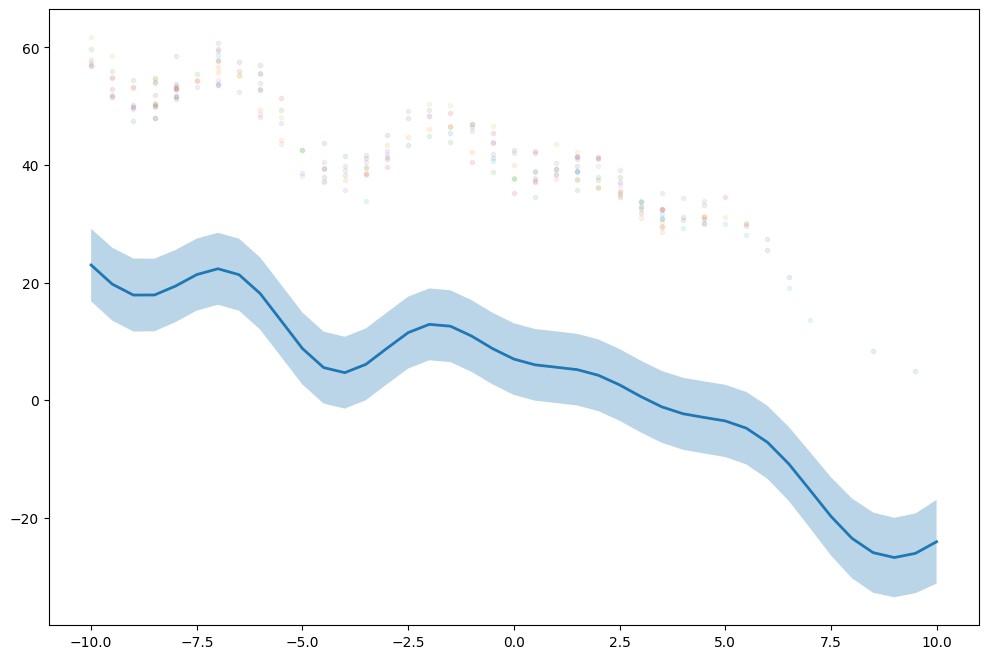

In [40]:
plot_mean_process_magma(model)
plt.show()

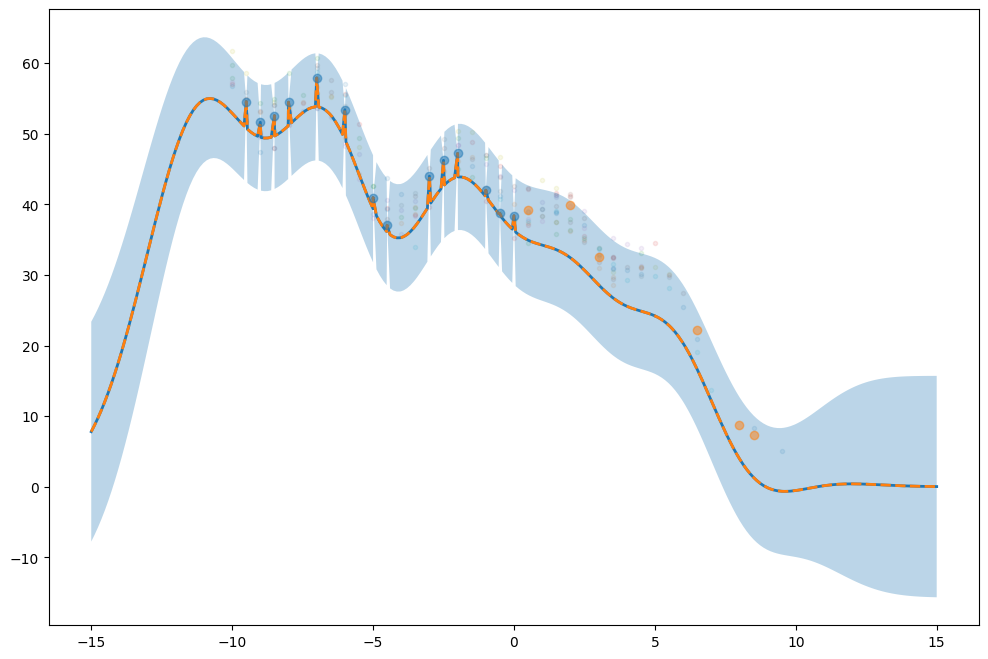

In [41]:
plot_predictions_magma(model, plot_as="process", task_id=0)
plt.show()

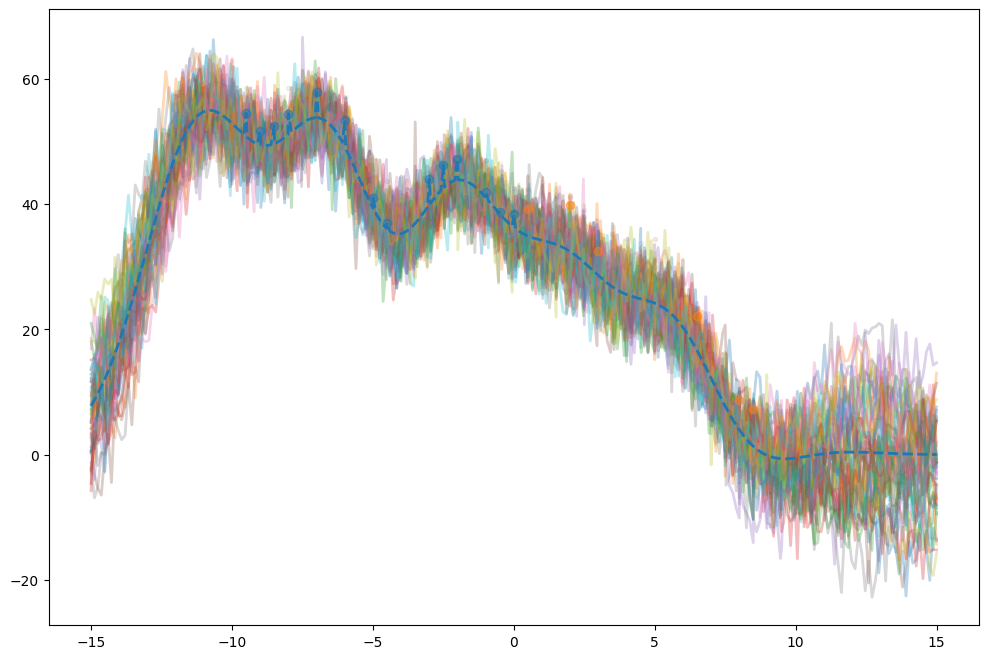

In [42]:
plot_predictions_magma(model, plot_as="samples", task_id=0, nb_samples=50)
plt.show()

#### Distinct Input, Distinct HP

##### Setup

In [43]:
db = pd.read_csv(f"../datasets/K=1/{test_db_size}_distinct_input_distinct_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [44]:
mean_kernel = SEMagmaKernel(length_scale=.3, variance=1.)
task_kernel_train = SEMagmaKernel(length_scale=.6, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kernel_pred = deepcopy(task_kernel_train)

prior_mean = ZeroMean()

likelihood = BaseLikelihood()

In [45]:
model = Magma(likelihood=likelihood, prior_mean=prior_mean, mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=False)

In [46]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [47]:
model.fit()

2025-12-17 11:37:57,991 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.30, variance=1.00)
	Task kernel: SEMagmaKernel(length_scale=[0.60 ± 0.00]₁₆, variance=[1.00 ± 0.00]₁₆) + Diag(Exp([2.50 ± 0.00]₁₆))
2025-12-17 11:37:58,970 - INFO - Iteration    1	Llhs:   -4072.2178,     645.1731	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=1.42, variance=1.71)
	Task kernel: SEMagmaKernel(length_scale=[1.06 ± 0.73]₁₆, variance=[3.15 ± 0.70]₁₆) + Diag(Exp([-1.86 ± 2.08]₁₆))
2025-12-17 11:37:59,620 - INFO - Iteration    2	Llhs:   -3860.1500,     621.4479	Conv. Ratio: 0.05496	
	Mean kernel: SEMagmaKernel(length_scale=1.42, variance=1.71)
	Task kernel: SEMagmaKernel(length_scale=[0.98 ± 0.69]₁₆, variance=[3.01 ± 0.46]₁₆) + Diag(Exp([-2.22 ± 2.00]₁₆))
2025-12-17 11:37:59,674 - INFO - Iteration    3	Llhs:   -6013.9446,     614.2767	Conv. Ratio: 0.66723	
	Mean kernel: SEMagmaKernel(length_scale=1.62, variance=1.85)
	Task k

In [48]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [49]:
pred_mean, pred_cov = model.predict(grid)
pred_mean.shape, pred_cov.shape

((4, 291), (4, 291, 291))

##### Test

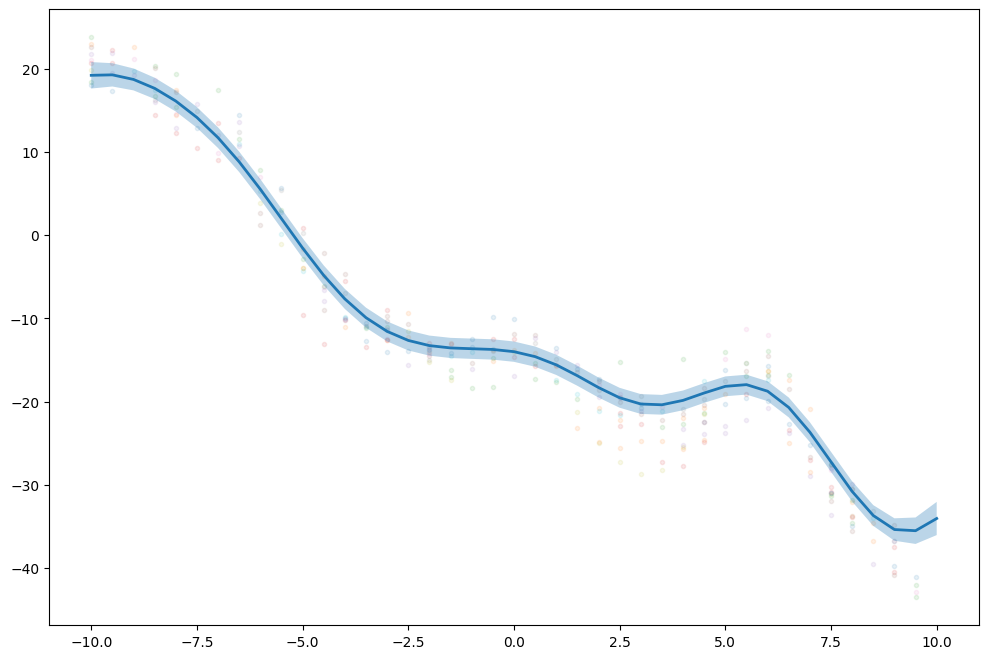

In [50]:
plot_mean_process_magma(model)
plt.show()

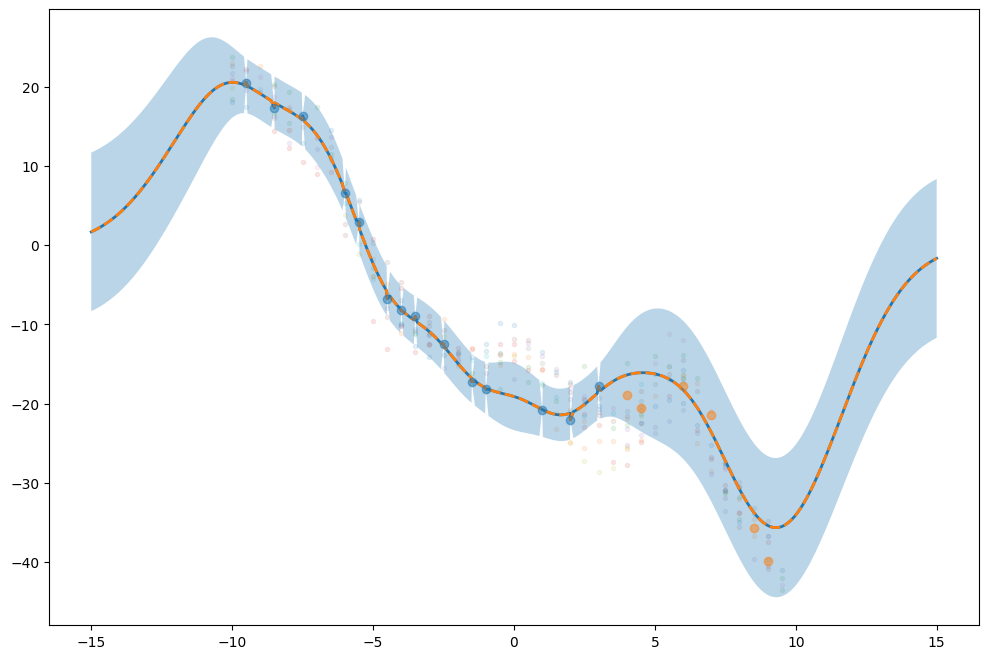

In [51]:
plot_predictions_magma(model, plot_as="process", task_id=0)
plt.show()

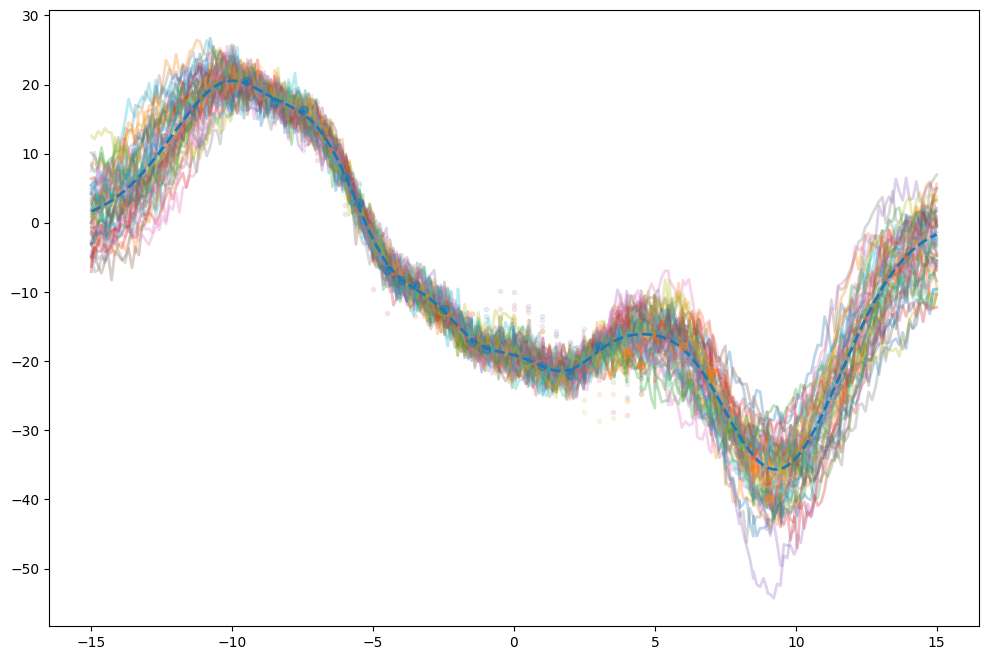

In [52]:
plot_predictions_magma(model, plot_as="samples", task_id=0, nb_samples=50)
plt.show()

---

### MagmaClust Scenarios

#### Shared HP + no Cluster HP

##### Setup

In [53]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [54]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

In [55]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kern, task_kernel_train=task_kern, task_kernel_pred=deepcopy(task_kern), shared_hp=True, cluster_hp=False)

In [56]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [57]:
model.fit()

2025-12-17 11:38:02,438 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.20, variance=5.00)
	Task kernel: SEMagmaKernel(length_scale=0.20, variance=1.00) + Diag(Exp(2.50))
2025-12-17 11:38:03,868 - INFO - Iteration    1	Llhs:     244.9715,     675.2237	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.33, variance=6.02)
	Task kernel: SEMagmaKernel(length_scale=-0.64, variance=2.06) + Diag(Exp(-3.32))
2025-12-17 11:38:05,076 - INFO - Iteration    2	Llhs:     232.4694,     586.6118	Conv. Ratio: 0.10988	
	Mean kernel: SEMagmaKernel(length_scale=0.38, variance=6.10)
	Task kernel: SEMagmaKernel(length_scale=-0.28, variance=1.70) + Diag(Exp(-2.85))
2025-12-17 11:38:05,109 - INFO - Iteration    3	Llhs:     217.0415,     539.4541	Conv. Ratio: 0.07641	
	Mean kernel: SEMagmaKernel(length_scale=0.43, variance=6.09)
	Task kernel: SEMagmaKernel(length_scale=-0.01, variance=1.58) + Diag(Exp(-2.79))
2025-12-17 11:38:05,12

In [58]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [59]:
pred_means, pred_covs = model.predict(grid)
pred_means.shape, pred_covs.shape

((4, 4, 291), (4, 4, 291, 291))

##### Test

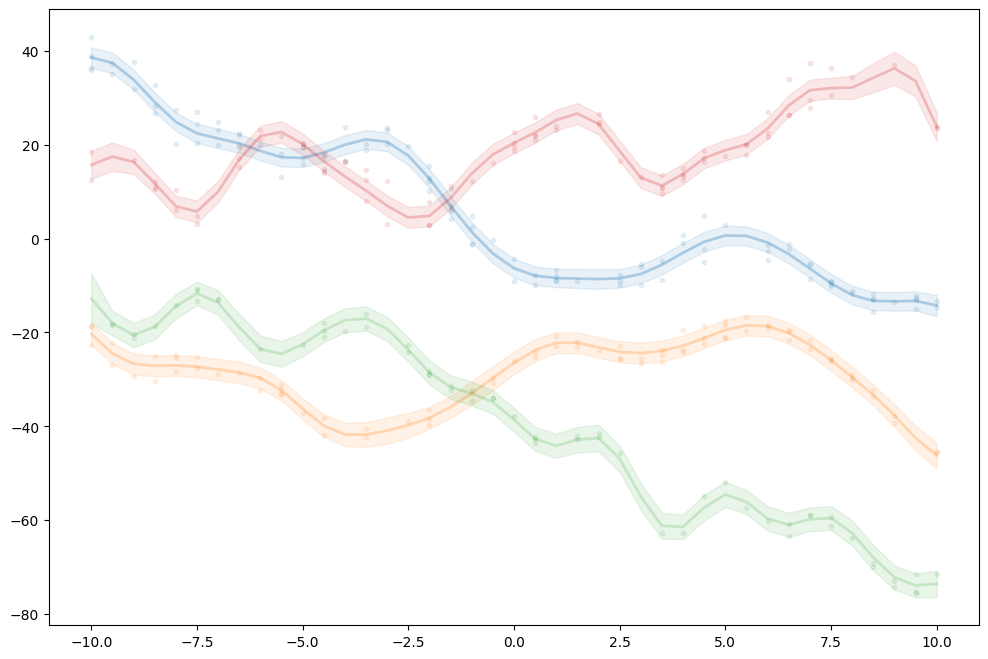

In [60]:
plot_mean_processes_magmaclust(model)
plt.show()

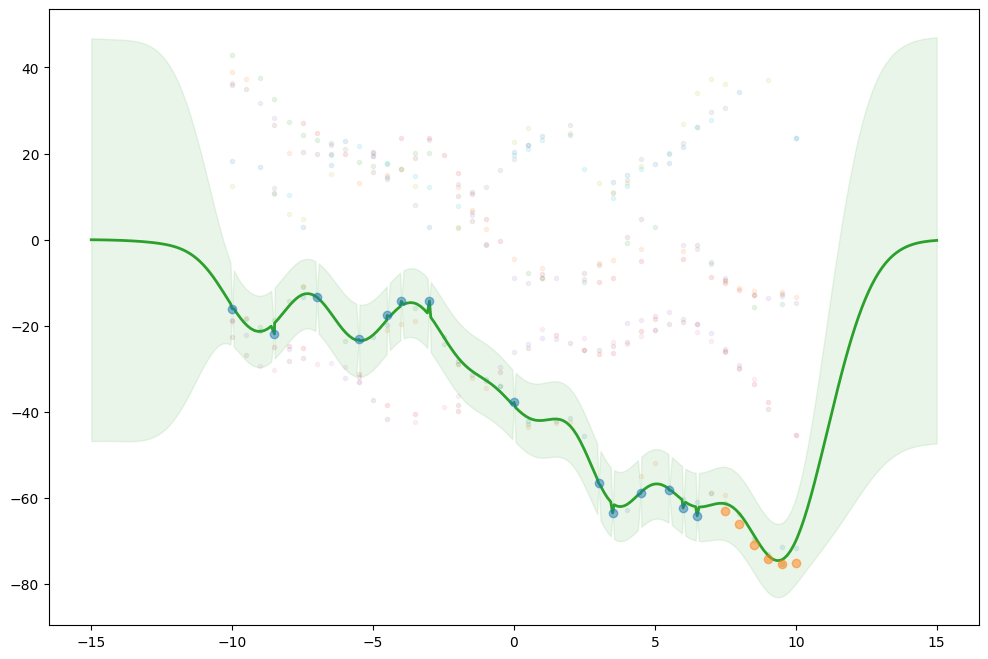

In [61]:
plot_predictions_magmaclust(model, plot_as="process", task_id=0)
plt.show()

#### Shared HP + Cluster HP

##### Setup

In [62]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [63]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

In [64]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kern, task_kernel_train=task_kern, task_kernel_pred=deepcopy(task_kern), shared_hp=True, cluster_hp=True)

In [65]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [66]:
model.fit()

2025-12-17 11:38:06,750 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.20, variance=5.00)
	Task kernel: SEMagmaKernel(length_scale=[0.20 ± 0.00]₄, variance=[1.00 ± 0.00]₄) + Diag(Exp([2.50 ± 0.00]₄))
2025-12-17 11:38:07,642 - INFO - Iteration    1	Llhs:     244.9715,     673.4369	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.33, variance=6.02)
	Task kernel: SEMagmaKernel(length_scale=[-0.69 ± 0.11]₄, variance=[2.04 ± 0.15]₄) + Diag(Exp([-4.48 ± 1.48]₄))
2025-12-17 11:38:08,401 - INFO - Iteration    2	Llhs:     232.4945,     584.5074	Conv. Ratio: 0.11042	
	Mean kernel: SEMagmaKernel(length_scale=0.38, variance=6.10)
	Task kernel: SEMagmaKernel(length_scale=[-0.39 ± 0.22]₄, variance=[1.63 ± 0.24]₄) + Diag(Exp([-4.10 ± 1.70]₄))
2025-12-17 11:38:08,544 - INFO - Iteration    3	Llhs:     217.1772,     531.0113	Conv. Ratio: 0.08423	
	Mean kernel: SEMagmaKernel(length_scale=0.43, variance=6.09)
	Task kernel: 

In [67]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [68]:
pred_means, pred_covs = model.predict(grid)
pred_means.shape, pred_covs.shape

((4, 4, 291), (4, 4, 291, 291))

##### Test

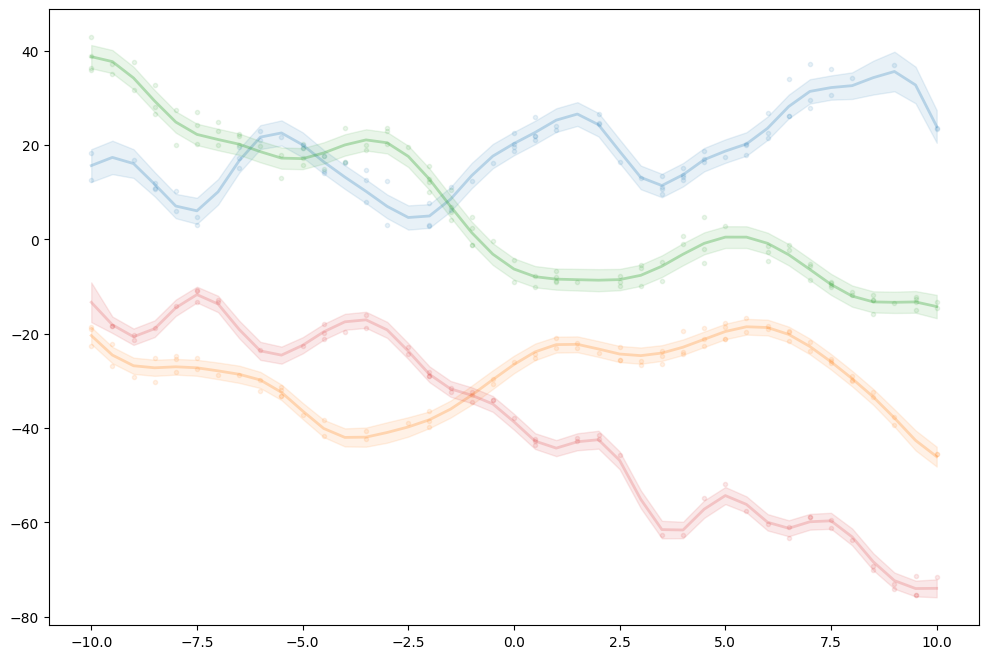

In [69]:
plot_mean_processes_magmaclust(model)
plt.show()

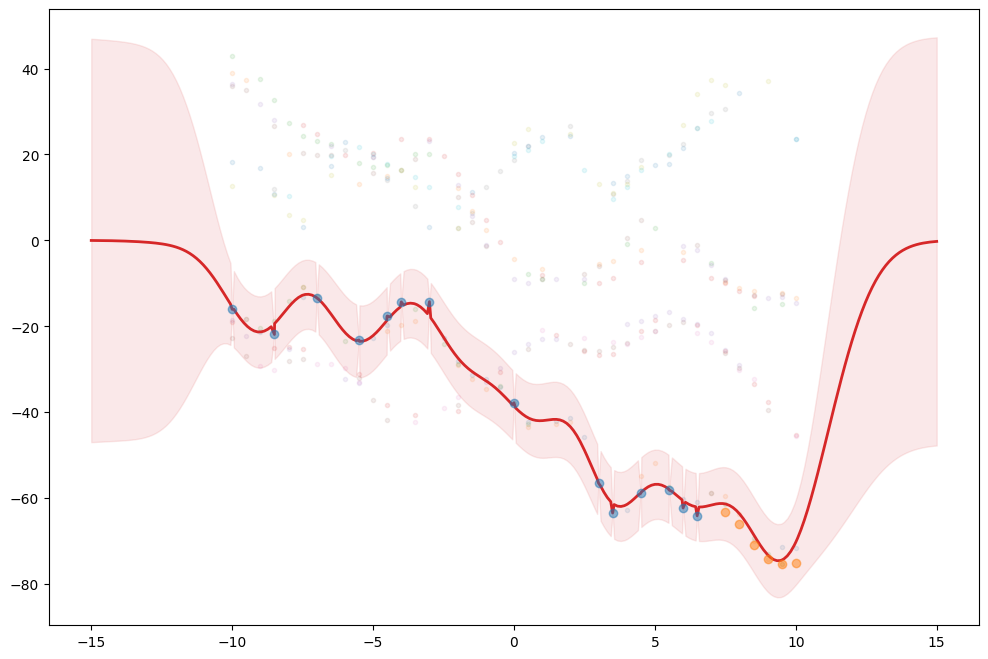

In [70]:
plot_predictions_magmaclust(model, plot_as="process", task_id=0)
plt.show()

#### Distinct HP + No Cluster HP

##### Setup

In [71]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_distinct_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [72]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

In [73]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kern, task_kernel_train=task_kern, task_kernel_pred=deepcopy(task_kern), shared_hp=False, cluster_hp=False)

In [74]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [75]:
model.fit()

2025-12-17 11:38:10,267 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.20, variance=5.00)
	Task kernel: SEMagmaKernel(length_scale=[0.20 ± 0.00]₁₆, variance=[1.00 ± 0.00]₁₆) + Diag(Exp([2.50 ± 0.00]₁₆))
2025-12-17 11:38:11,141 - INFO - Iteration    1	Llhs:     272.1984,     817.6028	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.36, variance=6.54)
	Task kernel: SEMagmaKernel(length_scale=[0.18 ± 1.58]₁₆, variance=[3.04 ± 1.31]₁₆) + Diag(Exp([-2.72 ± 3.64]₁₆))
2025-12-17 11:38:12,081 - INFO - Iteration    2	Llhs:     260.6348,     705.2451	Conv. Ratio: 0.11371	
	Mean kernel: SEMagmaKernel(length_scale=0.39, variance=6.58)
	Task kernel: SEMagmaKernel(length_scale=[0.33 ± 1.42]₁₆, variance=[2.49 ± 1.37]₁₆) + Diag(Exp([-2.87 ± 3.29]₁₆))
2025-12-17 11:38:12,157 - INFO - Iteration    3	Llhs:     248.7732,     618.2414	Conv. Ratio: 0.10236	
	Mean kernel: SEMagmaKernel(length_scale=0.43, variance=6.58)
	Task k

In [76]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [77]:
pred_means, pred_covs = model.predict(grid)
pred_means.shape, pred_covs.shape

TypeError: mul got incompatible shapes for broadcasting: (4, 4), (4, 16).

##### Test

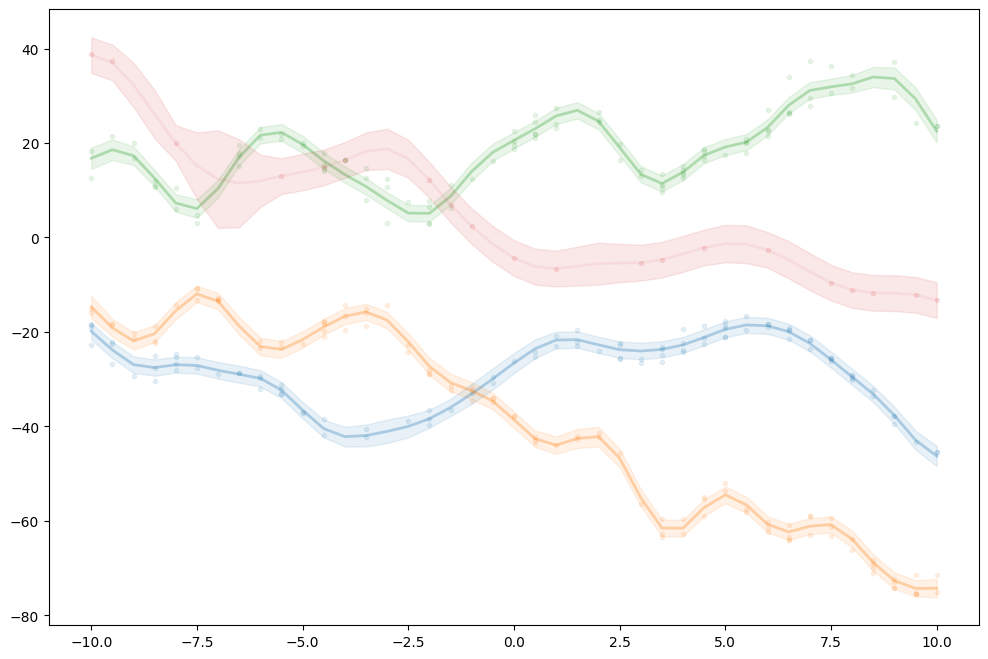

In [73]:
plot_mean_processes_magmaclust(model)
plt.show()

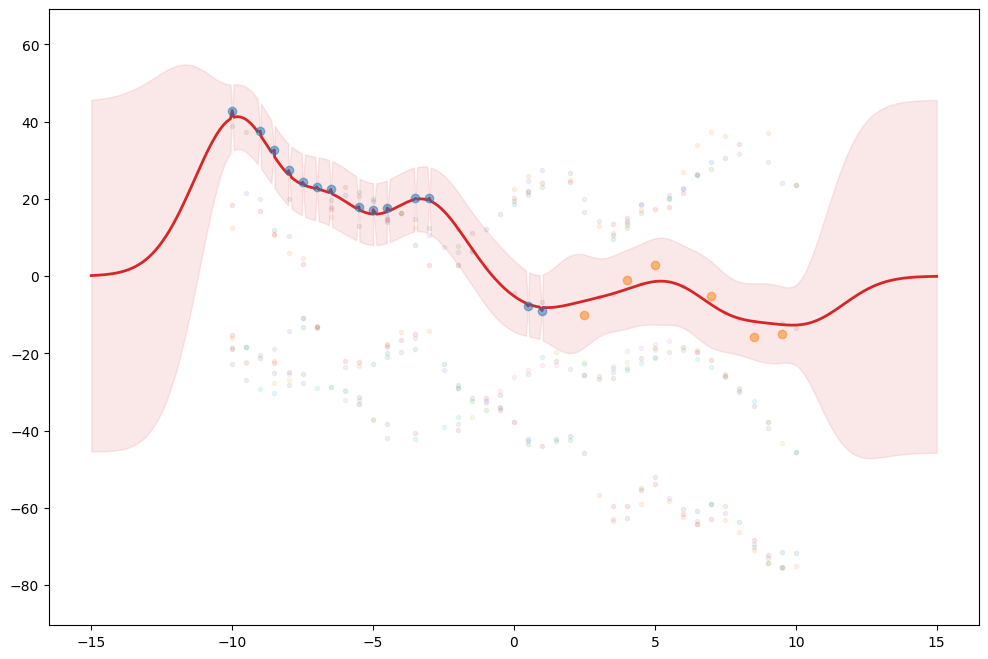

In [88]:
plot_predictions_magmaclust(model, plot_as="process", task_id=0)
plt.show()

#### Distinct HP + Cluster HP

##### Setup

In [78]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_distinct_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [79]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

In [80]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kern, task_kernel_train=task_kern, task_kernel_pred=deepcopy(task_kern), shared_hp=False, cluster_hp=True)

In [81]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [82]:
model.fit()

2025-12-17 11:44:13,919 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.20, variance=5.00)
	Task kernel: SEMagmaKernel(length_scale=[0.20 ± 0.00]₄ₓ₁₆, variance=[1.00 ± 0.00]₄ₓ₁₆) + Diag(Exp([2.50 ± 0.00]₄ₓ₁₆))
2025-12-17 11:44:14,956 - INFO - Iteration    1	Llhs:     272.1984,    4987.0575	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.36, variance=6.54)
	Task kernel: SEMagmaKernel(length_scale=[2.50 ± 2.63]₄ₓ₁₆, variance=[5.11 ± 2.68]₄ₓ₁₆) + Diag(Exp([3.08 ± 4.22]₄ₓ₁₆))
2025-12-17 11:44:15,832 - INFO - Iteration    2	Llhs:     260.5605,    4755.5769	Conv. Ratio: 0.04623	
	Mean kernel: SEMagmaKernel(length_scale=0.39, variance=6.58)
	Task kernel: SEMagmaKernel(length_scale=[2.41 ± 2.39]₄ₓ₁₆, variance=[5.65 ± 2.83]₄ₓ₁₆) + Diag(Exp([2.16 ± 4.30]₄ₓ₁₆))
2025-12-17 11:44:16,143 - INFO - Iteration    3	Llhs:     248.0084,    4492.0900	Conv. Ratio: 0.05503	
	Mean kernel: SEMagmaKernel(length_scale=0.43, varian

In [83]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [84]:
pred_means, pred_covs = model.predict(grid)
pred_means.shape, pred_covs.shape

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * most axes (3 of them) had size 4, e.g. axis 0 of argument kernel.left_kernel.length_scale of type float64[4];
  * one axis had size 16: axis 0 of argument x1 of type float64[16,20,1]

##### Test

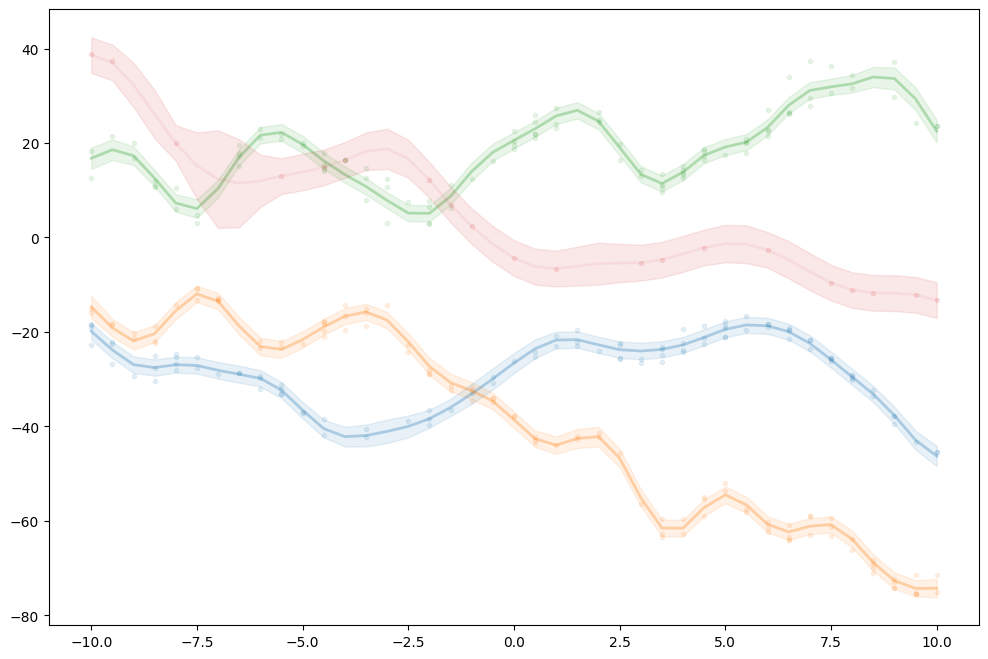

In [73]:
plot_mean_processes_magmaclust(model)
plt.show()

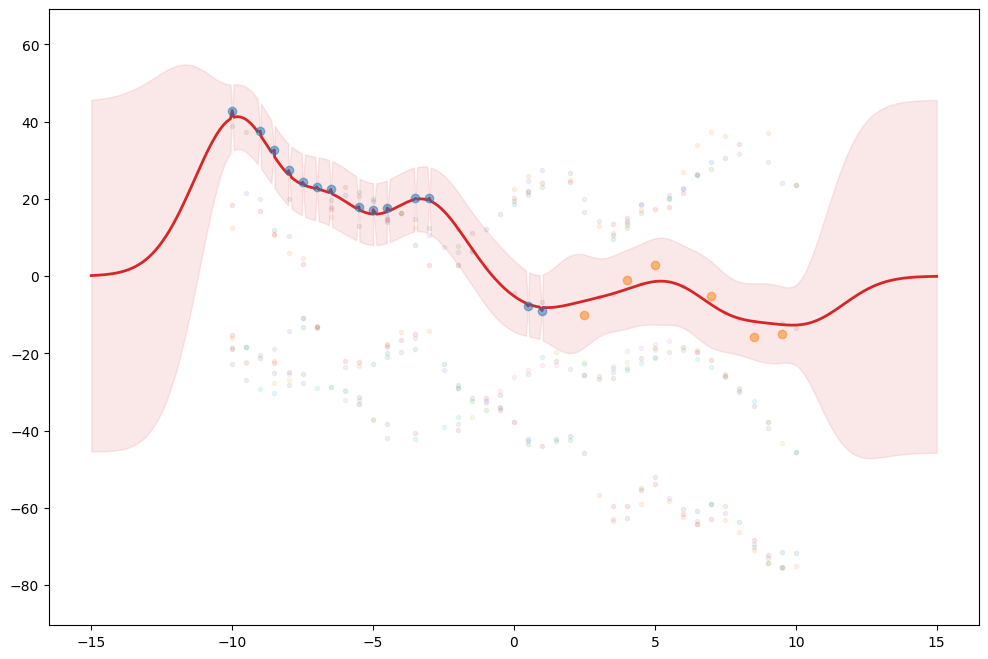

In [88]:
plot_predictions_magmaclust(model, plot_as="process", task_id=0)
plt.show()

---

## Conclusion

---